# 03 — Author Deep-Learning Reproduction

This notebook reproduces the deep-learning family from the Ben-Sarc reference paper using the current project protocol.

Output rule used here:

```text
04_outputs/
├── reports/
├── predictions/
├── figures/
├── tables/
└── diagrams/
```

No notebook-specific output folder is created.

In [1]:
!pip install tensorflow


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
# ==============================================
# 0. Imports and deterministic setup
# ==============================================

import os
import re
import json
import time
import random
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.initializers import Constant

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.18.1
GPU devices: []


In [3]:
# ==============================================
# 1. Project paths, output folders, and switches
# ==============================================

CWD = Path.cwd().resolve()

# If this notebook is run from 02_notebooks, project root is one level up.
# If it is run from project root, project root is current directory.
if CWD.name == "02_notebooks":
    REPO = CWD.parent
else:
    REPO = CWD

PROTOCOL = "same_split"       # Options: "same_split", "paper_60_20_20"
RUN_ALL_MODELS = True

# GloVe settings.
# If 300d is missing but internet is available, set AUTO_DOWNLOAD_GLOVE_300D=True on RunPod.
AUTO_DOWNLOAD_GLOVE_300D = True
REQUIRE_GLOVE_FOR_GLOVE_MODELS = True

# Data paths.
SPLIT_DIR = REPO / "01_data" / "interim" / "splits"
FULL_DATA_PATH = REPO / "01_data" / "processed" / "binary" / "ben_sarc_binary.csv"

# Only these five output folders are used.
OUT_ROOT = REPO / "04_outputs"

REPORT_DIR = OUT_ROOT / "reports"
PREDICTION_DIR = OUT_ROOT / "predictions"
FIGURE_DIR = OUT_ROOT / "figures"
TABLE_DIR = OUT_ROOT / "tables"
DIAGRAM_DIR = OUT_ROOT / "diagrams"

for d in [REPORT_DIR, PREDICTION_DIR, FIGURE_DIR, TABLE_DIR, DIAGRAM_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# GloVe paths.
GLOVE_DIR = REPO / "01_data" / "external" / "glove"
GLOVE_DIR.mkdir(parents=True, exist_ok=True)

GLOVE_300_TXT = GLOVE_DIR / "bn_glove.39M.300d.txt"
GLOVE_300_ZIP = GLOVE_DIR / "bn_glove.39M.300d.zip"

GLOVE_100_TXT = GLOVE_DIR / "bn_glove.39M.100d.txt"
GLOVE_100_ZIP = GLOVE_DIR / "bn_glove.39M.100d.zip"

GLOVE_300_URL = "https://huggingface.co/sagorsarker/bangla-glove-vectors/resolve/main/bn_glove.39M.300d.zip"

CFG = {
    "vocab_size": 10000,
    "max_len": 100,
    "embed_dim": None,              # Auto-detected from selected GloVe file.
    "lstm_units": 100,
    "stacked_lstm_units": (128, 64),
    "cnn_filters": 100,
    "cnn_kernel_size": 4,
    "pool_size": 5,
    "dense_hidden": 1000,
    "dropout": 0.2,
    "recurrent_dropout": 0.2,
    "batch_size": 16,
    "epochs": 100,
    "patience": 2,
    "lr_no_glove": 1e-4,
    "lr_glove": 1e-5,
    "seed": SEED,
}

print("CWD:", CWD)
print("REPO:", REPO)
print("PROTOCOL:", PROTOCOL)
print("SPLIT_DIR:", SPLIT_DIR)
print("FULL_DATA_PATH:", FULL_DATA_PATH)
print("OUT_ROOT:", OUT_ROOT)
print("REPORT_DIR:", REPORT_DIR)
print("PREDICTION_DIR:", PREDICTION_DIR)
print("FIGURE_DIR:", FIGURE_DIR)
print("TABLE_DIR:", TABLE_DIR)
print("DIAGRAM_DIR:", DIAGRAM_DIR)
print("GLOVE_DIR:", GLOVE_DIR)

CWD: /Users/sefayet/Desktop/Github/Sarcasm_detection/02_notebooks
REPO: /Users/sefayet/Desktop/Github/Sarcasm_detection
PROTOCOL: same_split
SPLIT_DIR: /Users/sefayet/Desktop/Github/Sarcasm_detection/01_data/interim/splits
FULL_DATA_PATH: /Users/sefayet/Desktop/Github/Sarcasm_detection/01_data/processed/binary/ben_sarc_binary.csv
OUT_ROOT: /Users/sefayet/Desktop/Github/Sarcasm_detection/04_outputs
REPORT_DIR: /Users/sefayet/Desktop/Github/Sarcasm_detection/04_outputs/reports
PREDICTION_DIR: /Users/sefayet/Desktop/Github/Sarcasm_detection/04_outputs/predictions
FIGURE_DIR: /Users/sefayet/Desktop/Github/Sarcasm_detection/04_outputs/figures
TABLE_DIR: /Users/sefayet/Desktop/Github/Sarcasm_detection/04_outputs/tables
DIAGRAM_DIR: /Users/sefayet/Desktop/Github/Sarcasm_detection/04_outputs/diagrams
GLOVE_DIR: /Users/sefayet/Desktop/Github/Sarcasm_detection/01_data/external/glove


In [4]:
# ==============================================
# 2. Optional GloVe 300d download/extract
# ==============================================

def download_file(url, out_path):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    print(f"Downloading:\n  {url}\n-> {out_path}")
    urllib.request.urlretrieve(url, out_path)
    return out_path

def extract_zip(zip_path, target_dir):
    zip_path = Path(zip_path)
    target_dir = Path(target_dir)
    print(f"Extracting:\n  {zip_path}\n-> {target_dir}")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(target_dir)

if AUTO_DOWNLOAD_GLOVE_300D and not GLOVE_300_TXT.exists():
    if not GLOVE_300_ZIP.exists():
        download_file(GLOVE_300_URL, GLOVE_300_ZIP)
    extract_zip(GLOVE_300_ZIP, GLOVE_DIR)

if GLOVE_300_ZIP.exists() and not GLOVE_300_TXT.exists():
    extract_zip(GLOVE_300_ZIP, GLOVE_DIR)

if GLOVE_100_ZIP.exists() and not GLOVE_100_TXT.exists():
    extract_zip(GLOVE_100_ZIP, GLOVE_DIR)

print("GLOVE_300_TXT exists:", GLOVE_300_TXT.exists(), GLOVE_300_TXT)
print("GLOVE_100_TXT exists:", GLOVE_100_TXT.exists(), GLOVE_100_TXT)

GLOVE_300_TXT exists: True /Users/sefayet/Desktop/Github/Sarcasm_detection/01_data/external/glove/bn_glove.39M.300d.txt
GLOVE_100_TXT exists: True /Users/sefayet/Desktop/Github/Sarcasm_detection/01_data/external/glove/bn_glove.39M.100d.txt


In [5]:
# ==============================================
# 3. Select and verify GloVe file
# ==============================================

def detect_glove_dim(path):
    path = Path(path)
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.rstrip().split()
            if len(parts) > 2:
                return len(parts) - 1
    raise ValueError(f"Could not detect GloVe dimension from: {path}")

if GLOVE_300_TXT.exists():
    GLOVE_PATH = GLOVE_300_TXT
elif GLOVE_100_TXT.exists():
    GLOVE_PATH = GLOVE_100_TXT
else:
    GLOVE_PATH = None

if GLOVE_PATH is None:
    msg = (
        "No Bengali GloVe file found. Expected one of:\n"
        f"  {GLOVE_300_TXT}\n"
        f"  {GLOVE_100_TXT}\n\n"
        "On RunPod, either upload/extract the file there, or set AUTO_DOWNLOAD_GLOVE_300D=True and rerun cells 1-3."
    )
    if REQUIRE_GLOVE_FOR_GLOVE_MODELS:
        raise FileNotFoundError(msg)
    else:
        print("WARNING:", msg)
else:
    CFG["embed_dim"] = detect_glove_dim(GLOVE_PATH)
    print("Selected GloVe:", GLOVE_PATH)
    print("GloVe size MB:", round(GLOVE_PATH.stat().st_size / (1024 * 1024), 2))
    print("Detected embedding dim:", CFG["embed_dim"])

    with open(GLOVE_PATH, "r", encoding="utf-8", errors="ignore") as f:
        for _ in range(3):
            line = f.readline().strip()
            parts = line.split()
            print("Token:", parts[0], "| dim:", len(parts) - 1)

if CFG["embed_dim"] is None:
    CFG["embed_dim"] = 300

print("CFG['embed_dim']:", CFG["embed_dim"])

Selected GloVe: /Users/sefayet/Desktop/Github/Sarcasm_detection/01_data/external/glove/bn_glove.39M.300d.txt
GloVe size MB: 488.29
Detected embedding dim: 300
Token: ও | dim: 300
Token: এবং | dim: 300
Token: করে | dim: 300
CFG['embed_dim']: 300


In [6]:
# ==============================================
# 4. Load Ben-Sarc data
# ==============================================

def find_label_col(df):
    for c in ["label_binary", "label", "target", "class", "Label", "polarity"]:
        if c in df.columns:
            return c
    raise ValueError(f"No label column found. Columns: {list(df.columns)}")

def load_same_split():
    train_path = SPLIT_DIR / "ben_sarc_binary_train.csv"
    val_path = SPLIT_DIR / "ben_sarc_binary_val.csv"
    test_path = SPLIT_DIR / "ben_sarc_binary_test.csv"

    for p in [train_path, val_path, test_path]:
        if not p.exists():
            raise FileNotFoundError(f"Missing split file: {p}")

    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)

    label_col = find_label_col(train_df)

    for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        if "text" not in df.columns:
            raise ValueError(f"No text column found in {split_name}. Columns: {list(df.columns)}")
        if label_col not in df.columns:
            raise ValueError(f"Label column {label_col} missing in {split_name}.")

    return train_df, val_df, test_df, label_col

def load_paper_60_20_20():
    if not FULL_DATA_PATH.exists():
        raise FileNotFoundError(f"Missing processed dataset: {FULL_DATA_PATH}")

    df = pd.read_csv(FULL_DATA_PATH)
    label_col = find_label_col(df)

    if "text" not in df.columns:
        raise ValueError(f"No text column found. Columns: {list(df.columns)}")

    df = df[["text", label_col]].dropna().copy()
    df["text"] = df["text"].astype(str)
    df[label_col] = df[label_col].astype(int)

    train_df, temp_df = train_test_split(
        df,
        test_size=0.40,
        random_state=CFG["seed"],
        stratify=df[label_col],
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=CFG["seed"],
        stratify=temp_df[label_col],
    )

    return train_df, val_df, test_df, label_col

if PROTOCOL == "same_split":
    train_df, val_df, test_df, label_col = load_same_split()
elif PROTOCOL == "paper_60_20_20":
    train_df, val_df, test_df, label_col = load_paper_60_20_20()
else:
    raise ValueError("PROTOCOL must be 'same_split' or 'paper_60_20_20'.")

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print("\n", name)
    print("shape:", df.shape)
    print("labels:", df[label_col].astype(int).value_counts().sort_index().to_dict())

X_train_text = train_df["text"].astype(str).tolist()
y_train = train_df[label_col].astype(int).values

X_val_text = val_df["text"].astype(str).tolist()
y_val = val_df[label_col].astype(int).values

X_test_text = test_df["text"].astype(str).tolist()
y_test = test_df[label_col].astype(int).values

print("\nFinal sizes:")
print("Train:", len(X_train_text))
print("Val:", len(X_val_text))
print("Test:", len(X_test_text))
print("Label column:", label_col)


 train
shape: (20498, 6)
labels: {0: 10249, 1: 10249}

 val
shape: (2562, 6)
labels: {0: 1281, 1: 1281}

 test
shape: (2563, 6)
labels: {0: 1281, 1: 1282}

Final sizes:
Train: 20498
Val: 2562
Test: 2563
Label column: label_binary


In [7]:
# ==============================================
# 5. Split leakage / duplicate sanity check
# ==============================================

def clean_text_key(x):
    return " ".join(str(x).strip().split()).lower()

check_df = pd.concat(
    [
        pd.DataFrame({"split": "train", "text": X_train_text, "label": y_train}),
        pd.DataFrame({"split": "val", "text": X_val_text, "label": y_val}),
        pd.DataFrame({"split": "test", "text": X_test_text, "label": y_test}),
    ],
    ignore_index=True,
)

check_df["text_key"] = check_df["text"].map(clean_text_key)

split_summary = (
    check_df.groupby("split")
    .agg(rows=("text_key", "size"), unique_texts=("text_key", "nunique"))
    .reset_index()
)
split_summary["duplicate_rows_inside_split"] = split_summary["rows"] - split_summary["unique_texts"]

display(split_summary)

leakage = (
    check_df.groupby("text_key")
    .filter(lambda x: x["split"].nunique() > 1)
    .sort_values(["text_key", "split"])
)

label_conflicts = (
    check_df.groupby("text_key")
    .filter(lambda x: x["label"].nunique() > 1)
    .sort_values(["text_key", "label", "split"])
)

print("Leaking unique texts across train/val/test:", leakage["text_key"].nunique())
print("Duplicate texts with conflicting labels:", label_conflicts["text_key"].nunique())

split_summary_path = TABLE_DIR / f"03_split_duplicate_check_{PROTOCOL}.csv"
split_summary.to_csv(split_summary_path, index=False)
print("Saved:", split_summary_path)

if not leakage.empty:
    leakage_path = TABLE_DIR / f"03_split_leakage_examples_{PROTOCOL}.csv"
    leakage[["split", "label", "text"]].head(200).to_csv(leakage_path, index=False)
    print("WARNING: leakage examples saved:", leakage_path)
else:
    print("No exact text leakage across train/val/test.")

,split,rows,unique_texts,duplicate_rows_inside_split
0,test,2563,2563,0
1,train,20498,20498,0
2,val,2562,2562,0


Leaking unique texts across train/val/test: 0
Duplicate texts with conflicting labels: 0
Saved: /Users/sefayet/Desktop/Github/Sarcasm_detection/04_outputs/tables/03_split_duplicate_check_same_split.csv
No exact text leakage across train/val/test.


In [8]:
# ==============================================
# 6. Tokenizer and padded sequences
# ==============================================

tokenizer = Tokenizer(num_words=CFG["vocab_size"], oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

word_index = tokenizer.word_index
usable_vocab_size = min(CFG["vocab_size"], len(word_index) + 1)

def encode_texts(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(
        seqs,
        maxlen=CFG["max_len"],
        padding="post",
        truncating="post",
    )

X_train = encode_texts(X_train_text)
X_val = encode_texts(X_val_text)
X_test = encode_texts(X_test_text)

print("Tokenizer vocab size:", len(word_index))
print("Usable vocab size:", usable_vocab_size)
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

Tokenizer vocab size: 35686
Usable vocab size: 10000
X_train: (20498, 100)
X_val: (2562, 100)
X_test: (2563, 100)


In [9]:
# ==============================================
# 7. Load GloVe and build embedding matrix
# ==============================================

def load_glove_vectors(path, expected_dim):
    vectors = {}
    bad_lines = 0

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.rstrip().split()
            if len(parts) != expected_dim + 1:
                bad_lines += 1
                continue

            word = parts[0]
            try:
                vec = np.asarray(parts[1:], dtype="float32")
            except ValueError:
                bad_lines += 1
                continue

            vectors[word] = vec

    return vectors, bad_lines

if GLOVE_PATH is None:
    glove_vectors = {}
    embedding_matrix = None
    glove_coverage = 0.0
    print("No GloVe loaded.")
else:
    print("Loading GloVe vectors from:", GLOVE_PATH)
    start = time.time()
    glove_vectors, bad_lines = load_glove_vectors(GLOVE_PATH, CFG["embed_dim"])
    print("Loaded vectors:", len(glove_vectors))
    print("Bad/skipped lines:", bad_lines)
    print("Load seconds:", round(time.time() - start, 2))

    embedding_matrix = np.random.normal(
        loc=0.0,
        scale=0.05,
        size=(usable_vocab_size, CFG["embed_dim"]),
    ).astype("float32")

    embedding_matrix[0] = np.zeros(CFG["embed_dim"], dtype="float32")

    hits = 0
    misses = 0

    for word, i in word_index.items():
        if i >= usable_vocab_size:
            continue
        vec = glove_vectors.get(word)
        if vec is not None:
            embedding_matrix[i] = vec
            hits += 1
        else:
            misses += 1

    glove_coverage = hits / max(1, hits + misses)

    print("Embedding matrix:", embedding_matrix.shape)
    print("GloVe hits:", hits)
    print("GloVe misses:", misses)
    print("Coverage:", round(glove_coverage, 4))

    coverage_path = TABLE_DIR / f"03_glove_coverage_{PROTOCOL}.csv"
    pd.DataFrame([{
        "glove_path": str(GLOVE_PATH),
        "embed_dim": CFG["embed_dim"],
        "usable_vocab_size": usable_vocab_size,
        "hits": hits,
        "misses": misses,
        "coverage": glove_coverage,
    }]).to_csv(coverage_path, index=False)
    print("Saved:", coverage_path)

Loading GloVe vectors from: /Users/sefayet/Desktop/Github/Sarcasm_detection/01_data/external/glove/bn_glove.39M.300d.txt
Loaded vectors: 178153
Bad/skipped lines: 0
Load seconds: 4.76
Embedding matrix: (10000, 300)
GloVe hits: 8909
GloVe misses: 1090
Coverage: 0.891
Saved: /Users/sefayet/Desktop/Github/Sarcasm_detection/04_outputs/tables/03_glove_coverage_same_split.csv


In [10]:
# ==============================================
# 8. Reference Table 7 targets
# ==============================================

REFERENCE_TARGETS = {
    "LSTM": {
        "reference_accuracy": 0.7248,
        "reference_precision": 0.7252,
        "reference_recall": 0.7253,
        "reference_f1": 0.7253,
    },
    "LSTM+CNN": {
        "reference_accuracy": 0.6940,
        "reference_precision": 0.6931,
        "reference_recall": 0.6949,
        "reference_f1": 0.6939,
    },
    "LSTM+CNN+GloVe": {
        "reference_accuracy": 0.6609,
        "reference_precision": 0.6599,
        "reference_recall": 0.6592,
        "reference_f1": 0.6595,
    },
    "StackedLSTM+CNN+GloVe": {
        "reference_accuracy": 0.6591,
        "reference_precision": 0.6580,
        "reference_recall": 0.6588,
        "reference_f1": 0.6584,
    },
    "BiLSTM+CNN+GloVe": {
        "reference_accuracy": 0.6558,
        "reference_precision": 0.6567,
        "reference_recall": 0.6584,
        "reference_f1": 0.6575,
    },
    "BiLSTM+GloVe": {
        "reference_accuracy": 0.6164,
        "reference_precision": 0.6204,
        "reference_recall": 0.5866,
        "reference_f1": 0.6024,
    },
}

pd.DataFrame.from_dict(REFERENCE_TARGETS, orient="index").reset_index(names="label")

,label,reference_accuracy,reference_precision,reference_recall,reference_f1
0,LSTM,0.7248,0.7252,0.7253,0.7253
1,LSTM+CNN,0.6940,0.6931,0.6949,0.6939
2,LSTM+CNN+GloVe,0.6609,0.6599,0.6592,0.6595
3,StackedLSTM+CNN+GloVe,0.6591,0.6580,0.6588,0.6584
4,BiLSTM+CNN+GloVe,0.6558,0.6567,0.6584,0.6575
5,BiLSTM+GloVe,0.6164,0.6204,0.5866,0.6024


In [11]:
# ==============================================
# 9. Model builders
# ==============================================

def safe_name(label):
    return (
        label.replace("+", "_")
        .replace(" ", "_")
        .replace("/", "_")
        .replace("-", "_")
    )

def random_embedding(mask_zero=False):
    return layers.Embedding(
        input_dim=usable_vocab_size,
        output_dim=CFG["embed_dim"],
        input_length=CFG["max_len"],
        mask_zero=mask_zero,
        trainable=True,
        name="random_embedding_masked" if mask_zero else "random_embedding",
    )

def glove_embedding(mask_zero=False, trainable=False):
    if embedding_matrix is None:
        raise ValueError("embedding_matrix is None. GloVe models cannot run without GloVe.")
    return layers.Embedding(
        input_dim=usable_vocab_size,
        output_dim=CFG["embed_dim"],
        embeddings_initializer=Constant(embedding_matrix),
        input_length=CFG["max_len"],
        mask_zero=mask_zero,
        trainable=trainable,
        name="glove_embedding_masked" if mask_zero else "glove_embedding",
    )

def output_head(x, hidden_activation="tanh"):
    x = layers.Dense(CFG["dense_hidden"], activation=hidden_activation, name="dense_1000")(x)
    x = layers.Dropout(CFG["dropout"], name="dense_dropout")(x)
    return layers.Dense(1, activation="sigmoid", name="output")(x)

def build_lstm():
    inp = layers.Input(shape=(CFG["max_len"],), name="tokens")
    x = random_embedding(mask_zero=True)(inp)
    x = layers.LSTM(
        CFG["lstm_units"],
        dropout=CFG["dropout"],
        recurrent_dropout=CFG["recurrent_dropout"],
        name="lstm_100",
    )(x)
    out = output_head(x, hidden_activation="tanh")
    return models.Model(inp, out, name="LSTM")

def build_lstm_cnn():
    inp = layers.Input(shape=(CFG["max_len"],), name="tokens")
    x = random_embedding(mask_zero=False)(inp)
    x = layers.Conv1D(
        filters=CFG["cnn_filters"],
        kernel_size=CFG["cnn_kernel_size"],
        activation="tanh",
        padding="valid",
        name="conv1d_100_k4",
    )(x)
    x = layers.MaxPooling1D(pool_size=CFG["pool_size"], name="maxpool_size5")(x)
    x = layers.LSTM(
        CFG["lstm_units"],
        dropout=CFG["dropout"],
        recurrent_dropout=CFG["recurrent_dropout"],
        name="lstm_100",
    )(x)
    out = output_head(x, hidden_activation="tanh")
    return models.Model(inp, out, name="LSTM_CNN")

def build_lstm_cnn_glove():
    inp = layers.Input(shape=(CFG["max_len"],), name="tokens")
    x = glove_embedding(mask_zero=False, trainable=False)(inp)
    x = layers.Dropout(CFG["dropout"], name="embedding_dropout")(x)
    x = layers.Dense(CFG["dense_hidden"], activation="tanh", name="time_dense_1000")(x)
    x = layers.Conv1D(
        filters=CFG["cnn_filters"],
        kernel_size=CFG["cnn_kernel_size"],
        activation="tanh",
        padding="valid",
        name="conv1d_100_k4",
    )(x)
    x = layers.MaxPooling1D(pool_size=CFG["pool_size"], name="maxpool_size5")(x)
    x = layers.LSTM(
        CFG["lstm_units"],
        dropout=CFG["dropout"],
        recurrent_dropout=CFG["recurrent_dropout"],
        name="lstm_100",
    )(x)
    out = layers.Dense(1, activation="sigmoid", name="output")(x)
    return models.Model(inp, out, name="LSTM_CNN_GloVe")

def build_stacked_lstm_cnn_glove():
    inp = layers.Input(shape=(CFG["max_len"],), name="tokens")
    x = glove_embedding(mask_zero=False, trainable=False)(inp)
    x = layers.Dropout(CFG["dropout"], name="embedding_dropout")(x)
    x = layers.Dense(CFG["dense_hidden"], activation="tanh", name="time_dense_1000")(x)
    x = layers.Conv1D(
        filters=CFG["cnn_filters"],
        kernel_size=CFG["cnn_kernel_size"],
        activation="tanh",
        padding="valid",
        name="conv1d_100_k4",
    )(x)
    x = layers.MaxPooling1D(pool_size=CFG["pool_size"], name="maxpool_size5")(x)
    x = layers.LSTM(
        CFG["stacked_lstm_units"][0],
        return_sequences=True,
        dropout=CFG["dropout"],
        recurrent_dropout=CFG["recurrent_dropout"],
        name="lstm_128",
    )(x)
    x = layers.LSTM(
        CFG["stacked_lstm_units"][1],
        dropout=CFG["dropout"],
        recurrent_dropout=CFG["recurrent_dropout"],
        name="lstm_64",
    )(x)
    out = output_head(x, hidden_activation="tanh")
    return models.Model(inp, out, name="StackedLSTM_CNN_GloVe")

def build_bilstm_cnn_glove():
    inp = layers.Input(shape=(CFG["max_len"],), name="tokens")
    x = glove_embedding(mask_zero=False, trainable=False)(inp)
    x = layers.Dropout(CFG["dropout"], name="embedding_dropout")(x)
    x = layers.Dense(CFG["dense_hidden"], activation="tanh", name="time_dense_1000")(x)
    x = layers.Conv1D(
        filters=CFG["cnn_filters"],
        kernel_size=CFG["cnn_kernel_size"],
        activation="tanh",
        padding="valid",
        name="conv1d_100_k4",
    )(x)
    x = layers.MaxPooling1D(pool_size=CFG["pool_size"], name="maxpool_size5")(x)
    x = layers.Bidirectional(
        layers.LSTM(
            CFG["lstm_units"],
            dropout=CFG["dropout"],
            recurrent_dropout=CFG["recurrent_dropout"],
        ),
        name="bilstm_100",
    )(x)
    out = output_head(x, hidden_activation="tanh")
    return models.Model(inp, out, name="BiLSTM_CNN_GloVe")

def build_bilstm_glove():
    inp = layers.Input(shape=(CFG["max_len"],), name="tokens")
    x = glove_embedding(mask_zero=True, trainable=False)(inp)
    x = layers.Dropout(CFG["dropout"], name="embedding_dropout")(x)
    x = layers.Bidirectional(
        layers.LSTM(
            CFG["lstm_units"],
            dropout=CFG["dropout"],
            recurrent_dropout=CFG["recurrent_dropout"],
        ),
        name="bilstm_100",
    )(x)
    out = output_head(x, hidden_activation="relu")
    return models.Model(inp, out, name="BiLSTM_GloVe")

In [12]:
# ==============================================
# 10. Training and evaluation helper
# ==============================================

def compute_binary_metrics(y_true, y_prob):
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "test_accuracy": accuracy_score(y_true, y_pred),
        "test_macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "test_macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "test_macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "test_weighted_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "test_weighted_recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "test_weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
    }, y_pred

def train_and_evaluate(label, builder, lr):
    tf.keras.backend.clear_session()

    print("\n" + "=" * 90)
    print("Training:", label)
    print("Learning rate:", lr)
    print("=" * 90)

    model = builder()

    model.compile(
        optimizer=optimizers.Nadam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    model.summary()

    cb = [
        callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=CFG["patience"],
            restore_best_weights=True,
            verbose=1,
        )
    ]

    start = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        batch_size=CFG["batch_size"],
        epochs=CFG["epochs"],
        callbacks=cb,
        verbose=1,
    )

    elapsed = time.time() - start

    hist_df = pd.DataFrame(history.history)
    best_epoch = int(hist_df["val_loss"].idxmin()) + 1
    val_loss_best = float(hist_df["val_loss"].min())

    test_prob = model.predict(X_test, batch_size=CFG["batch_size"]).reshape(-1)
    metrics, y_pred = compute_binary_metrics(y_test, test_prob)

    cm = np.array(metrics["confusion_matrix"])
    class_report = classification_report(y_test, y_pred, digits=4, zero_division=0)

    print("\nTest metrics:")
    for k, v in metrics.items():
        if k != "confusion_matrix":
            print(f"{k}: {v:.4f}")
    print("Confusion matrix:")
    print(cm)
    print("Classification report:")
    print(class_report)

    sname = safe_name(label)

    # Save history to tables, not a separate notebook folder.
    history_path = TABLE_DIR / f"03_history_{sname}_{PROTOCOL}.csv"
    hist_df.to_csv(history_path, index=False)

    # Save predictions to predictions.
    prediction_path = PREDICTION_DIR / f"03_{sname}_{PROTOCOL}_test_predictions.csv"
    pd.DataFrame({
        "text": X_test_text,
        "y_true": y_test,
        "y_prob": test_prob,
        "y_pred": y_pred,
    }).to_csv(prediction_path, index=False)

    # Save report to reports.
    report_path = REPORT_DIR / f"03_{sname}_{PROTOCOL}_report.txt"
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(f"Model: {label}\n")
        f.write(f"Protocol: {PROTOCOL}\n")
        f.write(f"Learning rate: {lr}\n")
        f.write(f"Batch size: {CFG['batch_size']}\n")
        f.write(f"Max length: {CFG['max_len']}\n")
        f.write(f"Vocab size: {usable_vocab_size}\n")
        f.write(f"Embedding dim: {CFG['embed_dim']}\n")
        f.write(f"GloVe path: {str(GLOVE_PATH) if GLOVE_PATH is not None else 'None'}\n")
        f.write(f"GloVe coverage: {glove_coverage:.6f}\n")
        f.write(f"Epochs ran: {len(hist_df)}\n")
        f.write(f"Best epoch: {best_epoch}\n")
        f.write(f"Best val_loss: {val_loss_best:.6f}\n")
        f.write(f"Time seconds: {elapsed:.2f}\n\n")

        f.write("Test metrics:\n")
        for k, v in metrics.items():
            if k != "confusion_matrix":
                f.write(f"{k}: {v:.6f}\n")

        f.write("\nConfusion matrix:\n")
        f.write(str(cm))
        f.write("\n\nClassification report:\n")
        f.write(class_report)

    ref = REFERENCE_TARGETS[label]

    row = {
        "label": label,
        "test_macro_f1": metrics["test_macro_f1"],
        "test_accuracy": metrics["test_accuracy"],
        "val_loss_best": val_loss_best,
        "best_epoch": best_epoch,
        "time_seconds": elapsed,

        "test_macro_precision": metrics["test_macro_precision"],
        "test_macro_recall": metrics["test_macro_recall"],
        "test_weighted_precision": metrics["test_weighted_precision"],
        "test_weighted_recall": metrics["test_weighted_recall"],
        "test_weighted_f1": metrics["test_weighted_f1"],

        "reference_accuracy": ref["reference_accuracy"],
        "reference_precision": ref["reference_precision"],
        "reference_recall": ref["reference_recall"],
        "reference_f1": ref["reference_f1"],

        "gap_vs_reference_accuracy": metrics["test_accuracy"] - ref["reference_accuracy"],
        "gap_vs_reference_macro_f1": metrics["test_macro_f1"] - ref["reference_f1"],
        "gap_vs_reference_weighted_f1": metrics["test_weighted_f1"] - ref["reference_f1"],

        "epochs_ran": len(hist_df),
        "batch_size": CFG["batch_size"],
        "learning_rate": lr,
        "max_len": CFG["max_len"],
        "vocab_size": usable_vocab_size,
        "embed_dim": CFG["embed_dim"],
        "glove_path": str(GLOVE_PATH) if GLOVE_PATH is not None else "",
        "glove_coverage": glove_coverage,

        "history_path": str(history_path),
        "prediction_path": str(prediction_path),
        "report_path": str(report_path),
        "confusion_matrix": json.dumps(metrics["confusion_matrix"], ensure_ascii=False),
    }

    return row

In [13]:
# ==============================================
# 11. Run all six reference DL models
# ==============================================

experiments = [
    ("LSTM", build_lstm, CFG["lr_no_glove"]),
    ("LSTM+CNN", build_lstm_cnn, CFG["lr_no_glove"]),
    ("LSTM+CNN+GloVe", build_lstm_cnn_glove, CFG["lr_glove"]),
    ("StackedLSTM+CNN+GloVe", build_stacked_lstm_cnn_glove, CFG["lr_glove"]),
    ("BiLSTM+CNN+GloVe", build_bilstm_cnn_glove, CFG["lr_glove"]),
    ("BiLSTM+GloVe", build_bilstm_glove, CFG["lr_glove"]),
]

if not RUN_ALL_MODELS:
    experiments = experiments[:1]

print("Models to run:")
for label, _, _ in experiments:
    print("-", label)

results = []

for label, builder, lr in experiments:
    if "GloVe" in label and embedding_matrix is None:
        msg = f"Skipping {label}: GloVe embedding matrix is missing."
        if REQUIRE_GLOVE_FOR_GLOVE_MODELS:
            raise RuntimeError(msg)
        print("WARNING:", msg)
        continue

    row = train_and_evaluate(label, builder, lr)
    results.append(row)

results_df = pd.DataFrame(results)

model_order = {label: i for i, (label, _, _) in enumerate(experiments)}
results_df["__order"] = results_df["label"].map(model_order)
results_df = results_df.sort_values("__order").drop(columns=["__order"]).reset_index(drop=True)

display(results_df)

Models to run:
- LSTM
- LSTM+CNN
- LSTM+CNN+GloVe
- StackedLSTM+CNN+GloVe
- BiLSTM+CNN+GloVe
- BiLSTM+GloVe

Training: LSTM
Learning rate: 0.0001


/Users/sefayet/.pyenv/versions/3.11.6/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tokens (InputLayer) │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_embedding_m… │ (None, 100, 300)  │  3,000,000 │ tokens[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 100)       │          0 │ tokens[0][0]      │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_100 (LSTM)     │ (None, 100)       │    160,400 │ random_embedding… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1000 (Dense)  │ (None, 1000)      │    101,000 │ lstm_100[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_dropout       │ (None, 1000)      │          0 │ dense_1000[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │      1,001 │ dense_dropout[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,262,401 (12.45 MB)

...

 Total params: 3,522,801 (13.44 MB)

 Trainable params: 522,801 (1.99 MB)

 Non-trainable params: 3,000,000 (11.44 MB)

Epoch 1/100
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 71s 54ms/step - accuracy: 0.5510 - loss: 0.6886 - val_accuracy: 0.6206 - val_loss: 0.6733
Epoch 2/100
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 69s 54ms/step - accuracy: 0.6089 - loss: 0.6725 - val_accuracy: 0.6581 - val_loss: 0.6434
Epoch 3/100
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 73s 57ms/step - accuracy: 0.6400 - loss: 0.6490 - val_accuracy: 0.6733 - val_loss: 0.6123
Epoch 4/100
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 71s 55ms/step - accuracy: 0.6504 - loss: 0.6303 - val_accuracy: 0.6858 - val_loss: 0.5994
Epoch 5/100
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 72s 56ms/step - accuracy: 0.6621 - loss: 0.6211 - val_accuracy: 0.6889 - val_loss: 0.5939
Epoch 6/100
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 71s 56ms/step - accuracy: 0.6613 - loss: 0.6184 - val_accuracy: 0.6913 - val_loss: 0.5899
Epoch 7/100
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 72s 56ms/step - accuracy: 0.6674 - loss: 0.6138 - val_accuracy: 0.6920 - val_loss: 0.5870
Epoch 8/100
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 73s 57ms/step - accuracy: 

,label,test_macro_f1,test_accuracy,val_loss_best,best_epoch,time_seconds,test_macro_precision,test_macro_recall,test_weighted_precision,test_weighted_recall,...,learning_rate,max_len,vocab_size,embed_dim,glove_path,glove_coverage,history_path,prediction_path,report_path,confusion_matrix
0,LSTM,0.712348,0.714787,0.565354,1,140.836140,0.722257,0.714752,0.722242,0.714787,...,0.00010,100,10000,300,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,0.890989,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,"[[798, 483], [248, 1034]]"
1,LSTM+CNN,0.678149,0.689817,0.595369,2,81.206301,0.721847,0.689742,0.721814,0.689817,...,0.00010,100,10000,300,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,0.890989,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,"[[640, 641], [154, 1128]]"
2,LSTM+CNN+GloVe,0.708859,0.709715,0.561302,13,662.948527,0.712172,0.709694,0.712164,0.709715,...,0.00001,100,10000,300,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,0.890989,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,"[[840, 441], [303, 979]]"
3,StackedLSTM+CNN+GloVe,0.710093,0.710886,0.563330,10,624.048745,0.713179,0.710865,0.713170,0.710886,...,0.00001,100,10000,300,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,0.890989,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,"[[844, 437], [304, 978]]"
4,BiLSTM+CNN+GloVe,0.702920,0.703082,0.566055,12,703.839248,0.703512,0.703073,0.703508,0.703082,...,0.00001,100,10000,300,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,0.890989,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,"[[871, 410], [351, 931]]"
5,BiLSTM+GloVe,0.712697,0.713227,0.556943,37,2826.827571,0.714778,0.713210,0.714771,0.713227,...,0.00001,100,10000,300,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,0.890989,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,"[[859, 422], [313, 969]]"


In [14]:
# ==============================================
# 12. Save final result tables
# ==============================================

results_path = TABLE_DIR / "03_dl_results.csv"
results_df.to_csv(results_path, index=False)
print("Saved:", results_path)

gap_cols = [
    "label",
    "test_accuracy",
    "test_macro_f1",
    "test_weighted_f1",
    "reference_accuracy",
    "reference_f1",
    "gap_vs_reference_accuracy",
    "gap_vs_reference_macro_f1",
    "gap_vs_reference_weighted_f1",
    "best_epoch",
    "epochs_ran",
    "time_seconds",
    "history_path",
    "prediction_path",
    "report_path",
]

gap_df = results_df[[c for c in gap_cols if c in results_df.columns]].copy()

gap_path = TABLE_DIR / f"03_dl_reference_gap_{PROTOCOL}.csv"
gap_df.to_csv(gap_path, index=False)
print("Saved:", gap_path)

display(gap_df)

Saved: /Users/sefayet/Desktop/Github/Sarcasm_detection/04_outputs/tables/03_dl_results.csv
Saved: /Users/sefayet/Desktop/Github/Sarcasm_detection/04_outputs/tables/03_dl_reference_gap_same_split.csv


,label,test_accuracy,test_macro_f1,test_weighted_f1,reference_accuracy,reference_f1,gap_vs_reference_accuracy,gap_vs_reference_macro_f1,gap_vs_reference_weighted_f1,best_epoch,epochs_ran,time_seconds,history_path,prediction_path,report_path
0,LSTM,0.714787,0.712348,0.712359,0.7248,0.7253,-0.010013,-0.012952,-0.012941,1,3,140.836140,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...
1,LSTM+CNN,0.689817,0.678149,0.678172,0.6940,0.6939,-0.004183,-0.015751,-0.015728,2,4,81.206301,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...
2,LSTM+CNN+GloVe,0.709715,0.708859,0.708865,0.6609,0.6595,0.048815,0.049359,0.049365,13,15,662.948527,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...
3,StackedLSTM+CNN+GloVe,0.710886,0.710093,0.710099,0.6591,0.6584,0.051786,0.051693,0.051699,10,12,624.048745,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...
4,BiLSTM+CNN+GloVe,0.703082,0.702920,0.702922,0.6558,0.6575,0.047282,0.045420,0.045422,12,14,703.839248,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...
5,BiLSTM+GloVe,0.713227,0.712697,0.712702,0.6164,0.6024,0.096827,0.110297,0.110302,37,39,2826.827571,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...,/Users/sefayet/Desktop/Github/Sarcasm_detectio...


In [15]:
# ==============================================
# 13. Save LaTeX table
# ==============================================

latex_cols = [
    "label",
    "test_accuracy",
    "test_macro_f1",
    "test_weighted_f1",
    "reference_accuracy",
    "reference_f1",
    "gap_vs_reference_accuracy",
    "gap_vs_reference_macro_f1",
]

latex_df = results_df[[c for c in latex_cols if c in results_df.columns]].copy()

for c in latex_df.columns:
    if c != "label":
        latex_df[c] = latex_df[c].map(lambda x: f"{x:.4f}" if pd.notna(x) else "")

latex_str = latex_df.to_latex(
    index=False,
    escape=False,
    caption=f"Deep-learning reproduction results on Ben-Sarc under the {PROTOCOL} protocol.",
    label=f"tab:dl-reproduction-{PROTOCOL.replace('_', '-')}",
)

latex_path = TABLE_DIR / f"03_dl_results_{PROTOCOL}.tex"
latex_path.write_text(latex_str, encoding="utf-8")

print("Saved:", latex_path)
print(latex_str)

Saved: /Users/sefayet/Desktop/Github/Sarcasm_detection/04_outputs/tables/03_dl_results_same_split.tex
\begin{table}
\caption{Deep-learning reproduction results on Ben-Sarc under the same_split protocol.}
\label{tab:dl-reproduction-same-split}
\begin{tabular}{llllllll}
\toprule
label & test_accuracy & test_macro_f1 & test_weighted_f1 & reference_accuracy & reference_f1 & gap_vs_reference_accuracy & gap_vs_reference_macro_f1 \\
\midrule
LSTM & 0.7148 & 0.7123 & 0.7124 & 0.7248 & 0.7253 & -0.0100 & -0.0130 \\
LSTM+CNN & 0.6898 & 0.6781 & 0.6782 & 0.6940 & 0.6939 & -0.0042 & -0.0158 \\
LSTM+CNN+GloVe & 0.7097 & 0.7089 & 0.7089 & 0.6609 & 0.6595 & 0.0488 & 0.0494 \\
StackedLSTM+CNN+GloVe & 0.7109 & 0.7101 & 0.7101 & 0.6591 & 0.6584 & 0.0518 & 0.0517 \\
BiLSTM+CNN+GloVe & 0.7031 & 0.7029 & 0.7029 & 0.6558 & 0.6575 & 0.0473 & 0.0454 \\
BiLSTM+GloVe & 0.7132 & 0.7127 & 0.7127 & 0.6164 & 0.6024 & 0.0968 & 0.1103 \\
\bottomrule
\end{tabular}
\end{table}



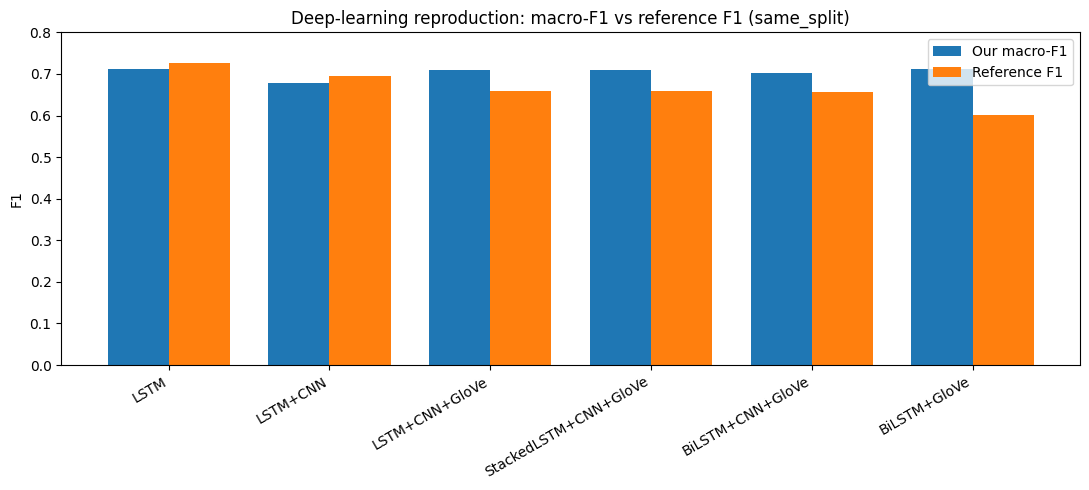

Saved: /Users/sefayet/Desktop/Github/Sarcasm_detection/04_outputs/figures/03_dl_macro_f1_vs_reference_same_split.png


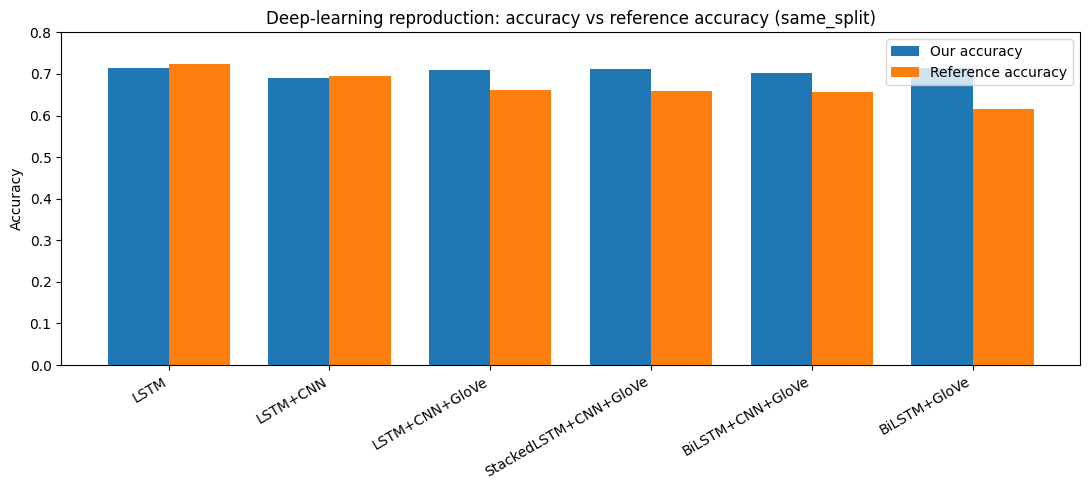

Saved: /Users/sefayet/Desktop/Github/Sarcasm_detection/04_outputs/figures/03_dl_accuracy_vs_reference_same_split.png


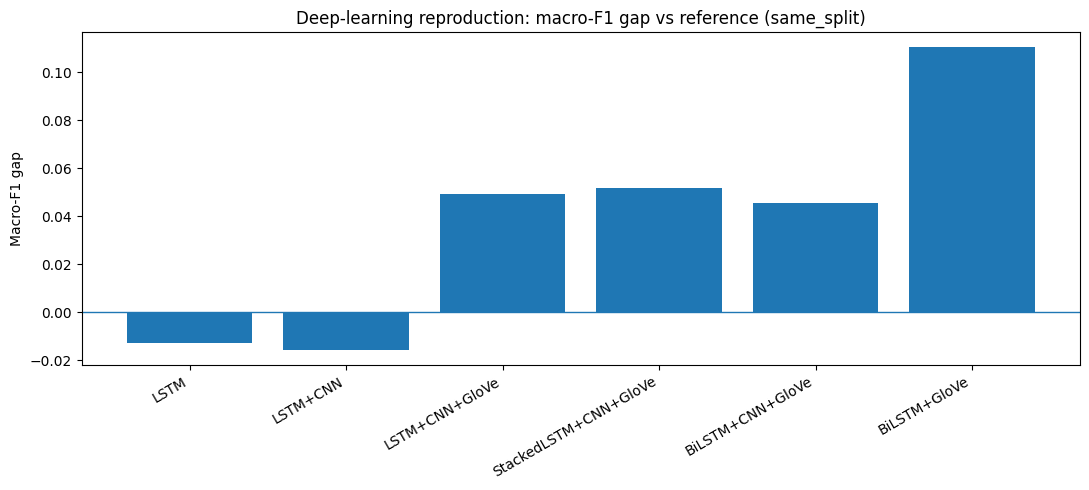

Saved: /Users/sefayet/Desktop/Github/Sarcasm_detection/04_outputs/figures/03_dl_macro_f1_gap_vs_reference_same_split.png


In [16]:
# ==============================================
# 14. Save figures
# ==============================================

plot_df = results_df.copy()

# Macro-F1 comparison.
plt.figure(figsize=(11, 5))
x = np.arange(len(plot_df))
width = 0.38

plt.bar(x - width / 2, plot_df["test_macro_f1"], width, label="Our macro-F1")
plt.bar(x + width / 2, plot_df["reference_f1"], width, label="Reference F1")

plt.xticks(x, plot_df["label"], rotation=30, ha="right")
plt.ylabel("F1")
plt.title(f"Deep-learning reproduction: macro-F1 vs reference F1 ({PROTOCOL})")
plt.ylim(0, max(0.80, plot_df[["test_macro_f1", "reference_f1"]].max().max() + 0.05))
plt.legend()
plt.tight_layout()

f1_fig = FIGURE_DIR / f"03_dl_macro_f1_vs_reference_{PROTOCOL}.png"
plt.savefig(f1_fig, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", f1_fig)

# Accuracy comparison.
plt.figure(figsize=(11, 5))
x = np.arange(len(plot_df))
width = 0.38

plt.bar(x - width / 2, plot_df["test_accuracy"], width, label="Our accuracy")
plt.bar(x + width / 2, plot_df["reference_accuracy"], width, label="Reference accuracy")

plt.xticks(x, plot_df["label"], rotation=30, ha="right")
plt.ylabel("Accuracy")
plt.title(f"Deep-learning reproduction: accuracy vs reference accuracy ({PROTOCOL})")
plt.ylim(0, max(0.80, plot_df[["test_accuracy", "reference_accuracy"]].max().max() + 0.05))
plt.legend()
plt.tight_layout()

acc_fig = FIGURE_DIR / f"03_dl_accuracy_vs_reference_{PROTOCOL}.png"
plt.savefig(acc_fig, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", acc_fig)

# Macro-F1 gap.
plt.figure(figsize=(11, 5))
plt.bar(plot_df["label"], plot_df["gap_vs_reference_macro_f1"])
plt.axhline(0, linewidth=1)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Macro-F1 gap")
plt.title(f"Deep-learning reproduction: macro-F1 gap vs reference ({PROTOCOL})")
plt.tight_layout()

gap_fig = FIGURE_DIR / f"03_dl_macro_f1_gap_vs_reference_{PROTOCOL}.png"
plt.savefig(gap_fig, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", gap_fig)

In [17]:
# ==============================================
# 15. Save summary report
# ==============================================

best_row = results_df.sort_values("test_macro_f1", ascending=False).iloc[0]
lstm_row = results_df[results_df["label"] == "LSTM"].iloc[0]

summary_text = f"""# Notebook 03 Deep-Learning Reproduction Summary

Protocol: `{PROTOCOL}`

## Output folders

This notebook writes only to:

- `04_outputs/reports`
- `04_outputs/predictions`
- `04_outputs/figures`
- `04_outputs/tables`
- `04_outputs/diagrams`

No notebook-specific output folder is used.

## LSTM sanity check

| Metric | Value |
|---|---:|
| LSTM test accuracy | {lstm_row["test_accuracy"]:.4f} |
| LSTM test macro-F1 | {lstm_row["test_macro_f1"]:.4f} |
| Reference LSTM accuracy | {lstm_row["reference_accuracy"]:.4f} |
| Reference LSTM F1 | {lstm_row["reference_f1"]:.4f} |

## Best reproduced DL model

| Field | Value |
|---|---|
| Model | {best_row["label"]} |
| Test accuracy | {best_row["test_accuracy"]:.4f} |
| Test macro-F1 | {best_row["test_macro_f1"]:.4f} |
| Test weighted-F1 | {best_row["test_weighted_f1"]:.4f} |

## Main saved files

- `{results_path}`
- `{gap_path}`
- `{latex_path}`
- `{f1_fig}`
- `{acc_fig}`
- `{gap_fig}`
"""

summary_path = REPORT_DIR / f"03_dl_reproduction_summary_{PROTOCOL}.md"
summary_path.write_text(summary_text, encoding="utf-8")

print("Saved:", summary_path)
print(summary_text)

Saved: /Users/sefayet/Desktop/Github/Sarcasm_detection/04_outputs/reports/03_dl_reproduction_summary_same_split.md
# Notebook 03 Deep-Learning Reproduction Summary

Protocol: `same_split`

## Output folders

This notebook writes only to:

- `04_outputs/reports`
- `04_outputs/predictions`
- `04_outputs/figures`
- `04_outputs/tables`
- `04_outputs/diagrams`

No notebook-specific output folder is used.

## LSTM sanity check

| Metric | Value |
|---|---:|
| LSTM test accuracy | 0.7148 |
| LSTM test macro-F1 | 0.7123 |
| Reference LSTM accuracy | 0.7248 |
| Reference LSTM F1 | 0.7253 |

## Best reproduced DL model

| Field | Value |
|---|---|
| Model | BiLSTM+GloVe |
| Test accuracy | 0.7132 |
| Test macro-F1 | 0.7127 |
| Test weighted-F1 | 0.7127 |

## Main saved files

- `/Users/sefayet/Desktop/Github/Sarcasm_detection/04_outputs/tables/03_dl_results.csv`
- `/Users/sefayet/Desktop/Github/Sarcasm_detection/04_outputs/tables/03_dl_reference_gap_same_split.csv`
- `/Users/sefayet/Desktop/Gith

In [18]:
# ==============================================
# 16. Final file check
# ==============================================

print("Tables:")
for p in sorted(TABLE_DIR.glob("03_*")):
    print(" ", p.relative_to(REPO))

print("\nFigures:")
for p in sorted(FIGURE_DIR.glob("03_*")):
    print(" ", p.relative_to(REPO))

print("\nReports:")
for p in sorted(REPORT_DIR.glob("03_*")):
    print(" ", p.relative_to(REPO))

print("\nPredictions:")
for p in sorted(PREDICTION_DIR.glob("03_*")):
    print(" ", p.relative_to(REPO))

Tables:
  04_outputs/tables/03_dl_reference_gap_same_split.csv
  04_outputs/tables/03_dl_results.csv
  04_outputs/tables/03_dl_results_same_split.tex
  04_outputs/tables/03_glove_coverage_same_split.csv
  04_outputs/tables/03_history_BiLSTM_CNN_GloVe_same_split.csv
  04_outputs/tables/03_history_BiLSTM_GloVe_same_split.csv
  04_outputs/tables/03_history_LSTM_CNN_GloVe_same_split.csv
  04_outputs/tables/03_history_LSTM_CNN_same_split.csv
  04_outputs/tables/03_history_LSTM_same_split.csv
  04_outputs/tables/03_history_StackedLSTM_CNN_GloVe_same_split.csv
  04_outputs/tables/03_split_duplicate_check_same_split.csv

Figures:
  04_outputs/figures/03_dl_accuracy_vs_reference_same_split.png
  04_outputs/figures/03_dl_macro_f1_gap_vs_reference_same_split.png
  04_outputs/figures/03_dl_macro_f1_vs_reference_same_split.png

Reports:
  04_outputs/reports/03_BiLSTM_CNN_GloVe_same_split_report.txt
  04_outputs/reports/03_BiLSTM_GloVe_same_split_report.txt
  04_outputs/reports/03_LSTM_CNN_GloVe_sam